# Hierarchical Additive-Kernel NB GP Demo

**Model:** $f_i = g(t_i) + h_{\ell_i}(t_i)$, with $g \sim \mathrm{GP}(0, k_g)$, $h_\ell \stackrel{\mathrm{iid}}{\sim} \mathrm{GP}(0, k_h)$, and $y_i \mid f_i, r \sim \mathrm{NB}(r, \sigma(f_i))$.

We generate synthetic data from known hyperparameters, fit with perturbed initializations, and check recovery.

In [1]:
import math, sys, numpy as np, torch
import matplotlib.pyplot as plt
from pathlib import Path

_ROOT = Path(".").resolve().parents[1]
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from pg_hierarchical import HierarchicalPGNegBinRegressor

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1. Generate synthetic data

In [2]:
def rff_gp_sample(x, *, seed, lengthscale, variance, n_features=2000):
    """Sample from GP(0, SE(ls, var)) via random Fourier features."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=np.float64).reshape(-1, 1)
    omega = rng.normal(0, 1.0 / lengthscale, size=(n_features, 1))
    phase = rng.uniform(0, 2 * np.pi, size=n_features)
    weights = rng.normal(size=n_features)
    features = math.sqrt(2.0 * variance / n_features) * np.cos(x @ omega.T + phase)
    return features @ weights

# True parameters
TRUE = dict(ls_g=0.2, var_g=1.5, ls_h=0.05, var_h=0.5, r=5.0)

n = 5000
L = 2
seed = 42
rng = np.random.default_rng(seed)

x = rng.uniform(0, 1, size=n)
locations = np.concatenate([np.zeros(n // 2, dtype=int),
                            np.ones(n - n // 2, dtype=int)])

# Global GP (shared)
g = rff_gp_sample(x, seed=seed + 100, lengthscale=TRUE["ls_g"], variance=TRUE["var_g"])

# Independent local GPs per location
h = np.zeros(n)
for ell in range(L):
    mask = locations == ell
    h[mask] = rff_gp_sample(x[mask], seed=seed + 200 + ell,
                             lengthscale=TRUE["ls_h"], variance=TRUE["var_h"])

f_true = g + h
prob = 1.0 / (1.0 + np.exp(-f_true))
y = rng.negative_binomial(TRUE["r"], 1 - prob).astype(np.float64)

print(f"n={n}, L={L}, y in [{int(y.min())}, {int(y.max())}], mean={y.mean():.1f}")

n=5000, L=2, y in [0, 155], mean=23.0


## 2. Visualize the true latent functions and observed counts

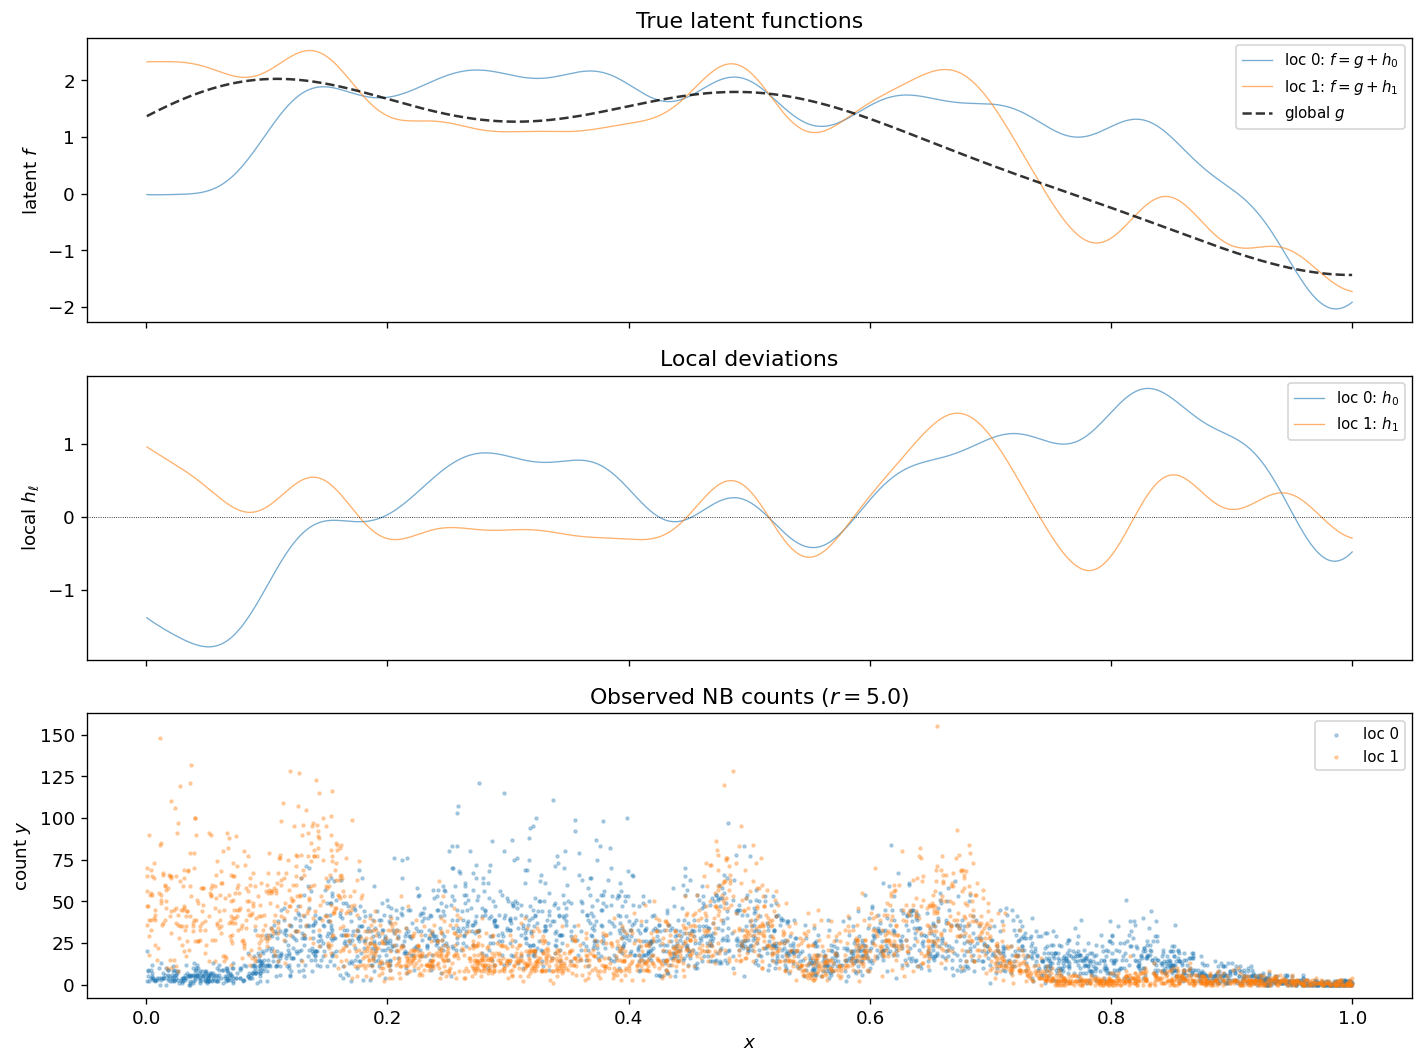

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
colors = ["#1f77b4", "#ff7f0e"]
order = np.argsort(x)

# Top: true latent f per location
ax = axes[0]
for ell in range(L):
    mask = locations == ell
    o = np.argsort(x[mask])
    ax.plot(x[mask][o], f_true[mask][o], color=colors[ell], alpha=0.6,
            label=f"loc {ell}: $f = g + h_{ell}$", lw=0.8)
ax.plot(x[order], g[order], "k--", lw=1.5, alpha=0.8, label="global $g$")
ax.set_ylabel("latent $f$")
ax.legend(fontsize=9)
ax.set_title("True latent functions")

# Middle: local h per location
ax = axes[1]
for ell in range(L):
    mask = locations == ell
    o = np.argsort(x[mask])
    ax.plot(x[mask][o], h[mask][o], color=colors[ell], alpha=0.6,
            label=f"loc {ell}: $h_{ell}$", lw=0.8)
ax.axhline(0, color="k", ls=":", lw=0.5)
ax.set_ylabel("local $h_\\ell$")
ax.legend(fontsize=9)
ax.set_title("Local deviations")

# Bottom: observed counts
ax = axes[2]
for ell in range(L):
    mask = locations == ell
    ax.scatter(x[mask], y[mask], s=3, alpha=0.3, color=colors[ell],
               label=f"loc {ell}")
ax.set_ylabel("count $y$")
ax.set_xlabel("$x$")
ax.legend(fontsize=9)
ax.set_title(f"Observed NB counts ($r={TRUE['r']}$)")

plt.tight_layout()
plt.show()

## 3. Fit the hierarchical model (perturbed initial hyperparameters)

In [4]:
INIT = dict(ls_g=0.35, var_g=0.8, ls_h=0.1, var_h=0.3, r=3.0)

model = HierarchicalPGNegBinRegressor(
    lengthscale_g_init=INIT["ls_g"],
    variance_g_init=INIT["var_g"],
    lengthscale_h_init=INIT["ls_h"],
    variance_h_init=INIT["var_h"],
    total_count=INIT["r"],
    learn_total_count=True,
    total_count_lr=0.02,
    total_count_update_freq=3,
    max_iter=80,
    e_step_iters=3,
    final_e_step_iters=5,
    lr_g=0.01,
    lr_h=0.05,
    n_e_probes=10,
    n_m_probes=10,
    cg_tol=1e-5,
    spectral_eps=1e-4,
    trunc_eps=1e-4,
    seed=123,
    verbose=1,
    device="cpu",
)

model.fit(x, y, locations)

[  0] ls_g=0.3465 var_g=0.8080 ls_h=0.0951 var_h=0.3154 r=3.000 mae=10.143 e_cg=55 m_cg=56


[  1] ls_g=0.3432 var_g=0.8153 ls_h=0.0905 var_h=0.3316 r=3.000 mae=9.220 e_cg=54 m_cg=59


[  2] ls_g=0.3399 var_g=0.8227 ls_h=0.0861 var_h=0.3485 r=3.061 mae=9.168 e_cg=56 m_cg=59


[  3] ls_g=0.3370 var_g=0.8305 ls_h=0.0821 var_h=0.3660 r=3.061 mae=9.139 e_cg=62 m_cg=62


[  4] ls_g=0.3344 var_g=0.8380 ls_h=0.0784 var_h=0.3840 r=3.061 mae=9.119 e_cg=63 m_cg=63


...

[ 75] ls_g=0.2273 var_g=1.4098 ls_h=0.0473 var_h=0.5396 r=4.613 mae=8.897 e_cg=107 m_cg=106


[ 76] ls_g=0.2263 var_g=1.4144 ls_h=0.0472 var_h=0.5391 r=4.613 mae=8.891 e_cg=106 m_cg=112


[ 77] ls_g=0.2250 var_g=1.4182 ls_h=0.0471 var_h=0.5382 r=4.668 mae=8.927 e_cg=110 m_cg=105


[ 78] ls_g=0.2238 var_g=1.4210 ls_h=0.0470 var_h=0.5373 r=4.668 mae=8.895 e_cg=110 m_cg=106


[ 79] ls_g=0.2228 var_g=1.4234 ls_h=0.0470 var_h=0.5362 r=4.668 mae=8.889 e_cg=111 m_cg=111


## 4. Hyperparameter recovery summary

In [5]:
import pandas as pd

summary = pd.DataFrame({
    "True":    [TRUE["ls_g"], TRUE["var_g"], TRUE["ls_h"], TRUE["var_h"], TRUE["r"]],
    "Init":    [INIT["ls_g"], INIT["var_g"], INIT["ls_h"], INIT["var_h"], INIT["r"]],
    "Learned": [model.lengthscale_g_, model.variance_g_,
                model.lengthscale_h_, model.variance_h_, model.total_count_],
}, index=["ls_g", "var_g", "ls_h", "var_h", "r"])
summary["Rel. Error"] = ((summary["Learned"] - summary["True"]) / summary["True"]).map("{:+.1%}".format)
summary

,True,Init,Learned,Rel. Error
ls_g,0.20,0.35,0.222803,+11.4%
var_g,1.50,0.80,1.423375,-5.1%
ls_h,0.05,0.10,0.046969,-6.1%
var_h,0.50,0.30,0.536202,+7.2%
r,5.00,3.00,4.668417,-6.6%


## 5. Hyperparameter learning curves

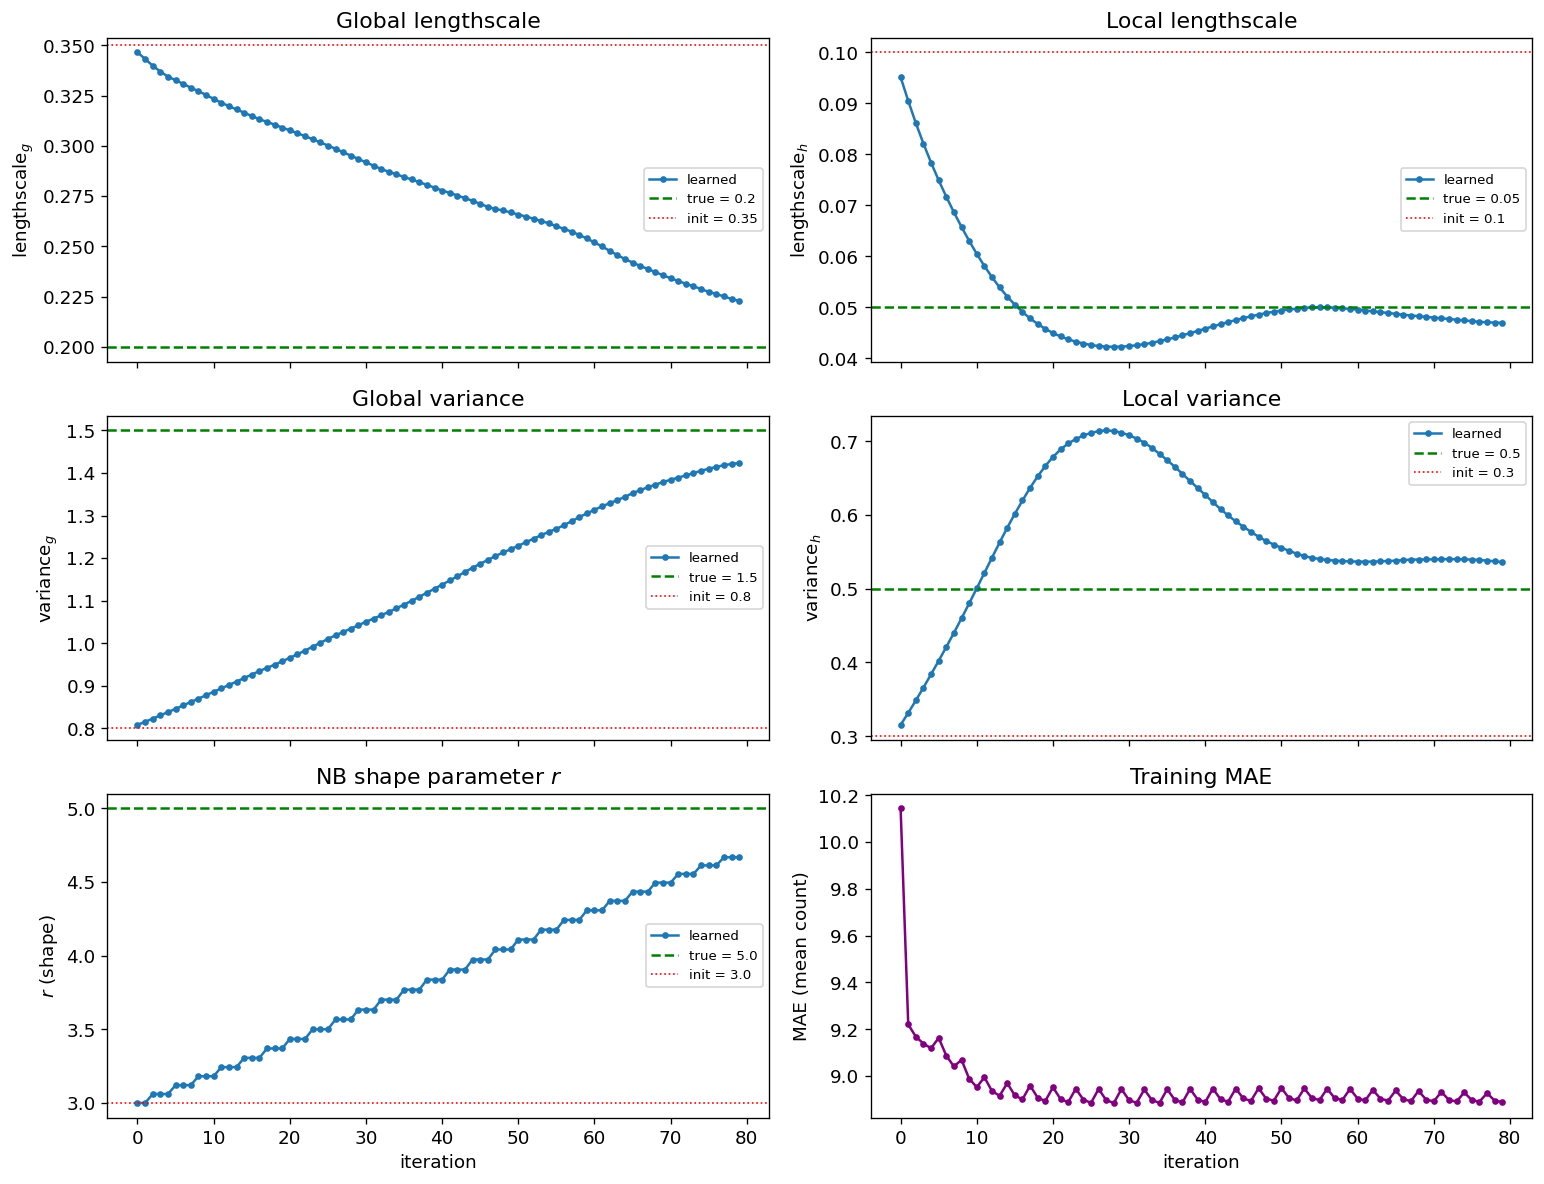

In [6]:
hist = model.history_
iters = [h["iter"] for h in hist]

fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)

# --- Row 0: lengthscales ---
ax = axes[0, 0]
ax.plot(iters, [h["ls_g"] for h in hist], "o-", ms=3, label="learned")
ax.axhline(TRUE["ls_g"], color="green", ls="--", lw=1.5, label=f"true = {TRUE['ls_g']}")
ax.axhline(INIT["ls_g"], color="red", ls=":", lw=1, label=f"init = {INIT['ls_g']}")
ax.set_ylabel("lengthscale$_g$")
ax.legend(fontsize=8)
ax.set_title("Global lengthscale")

ax = axes[0, 1]
ax.plot(iters, [h["ls_h"] for h in hist], "o-", ms=3, label="learned")
ax.axhline(TRUE["ls_h"], color="green", ls="--", lw=1.5, label=f"true = {TRUE['ls_h']}")
ax.axhline(INIT["ls_h"], color="red", ls=":", lw=1, label=f"init = {INIT['ls_h']}")
ax.set_ylabel("lengthscale$_h$")
ax.legend(fontsize=8)
ax.set_title("Local lengthscale")

# --- Row 1: variances ---
ax = axes[1, 0]
ax.plot(iters, [h["var_g"] for h in hist], "o-", ms=3, label="learned")
ax.axhline(TRUE["var_g"], color="green", ls="--", lw=1.5, label=f"true = {TRUE['var_g']}")
ax.axhline(INIT["var_g"], color="red", ls=":", lw=1, label=f"init = {INIT['var_g']}")
ax.set_ylabel("variance$_g$")
ax.legend(fontsize=8)
ax.set_title("Global variance")

ax = axes[1, 1]
ax.plot(iters, [h["var_h"] for h in hist], "o-", ms=3, label="learned")
ax.axhline(TRUE["var_h"], color="green", ls="--", lw=1.5, label=f"true = {TRUE['var_h']}")
ax.axhline(INIT["var_h"], color="red", ls=":", lw=1, label=f"init = {INIT['var_h']}")
ax.set_ylabel("variance$_h$")
ax.legend(fontsize=8)
ax.set_title("Local variance")

# --- Row 2: r and MAE ---
ax = axes[2, 0]
ax.plot(iters, [h["r"] for h in hist], "o-", ms=3, label="learned")
ax.axhline(TRUE["r"], color="green", ls="--", lw=1.5, label=f"true = {TRUE['r']}")
ax.axhline(INIT["r"], color="red", ls=":", lw=1, label=f"init = {INIT['r']}")
ax.set_ylabel("$r$ (shape)")
ax.set_xlabel("iteration")
ax.legend(fontsize=8)
ax.set_title("NB shape parameter $r$")

ax = axes[2, 1]
ax.plot(iters, [h["mae"] for h in hist], "o-", ms=3, color="purple")
ax.set_ylabel("MAE (mean count)")
ax.set_xlabel("iteration")
ax.set_title("Training MAE")

plt.tight_layout()
plt.show()

## 6. Posterior fit: learned $\mu$ vs true $f$

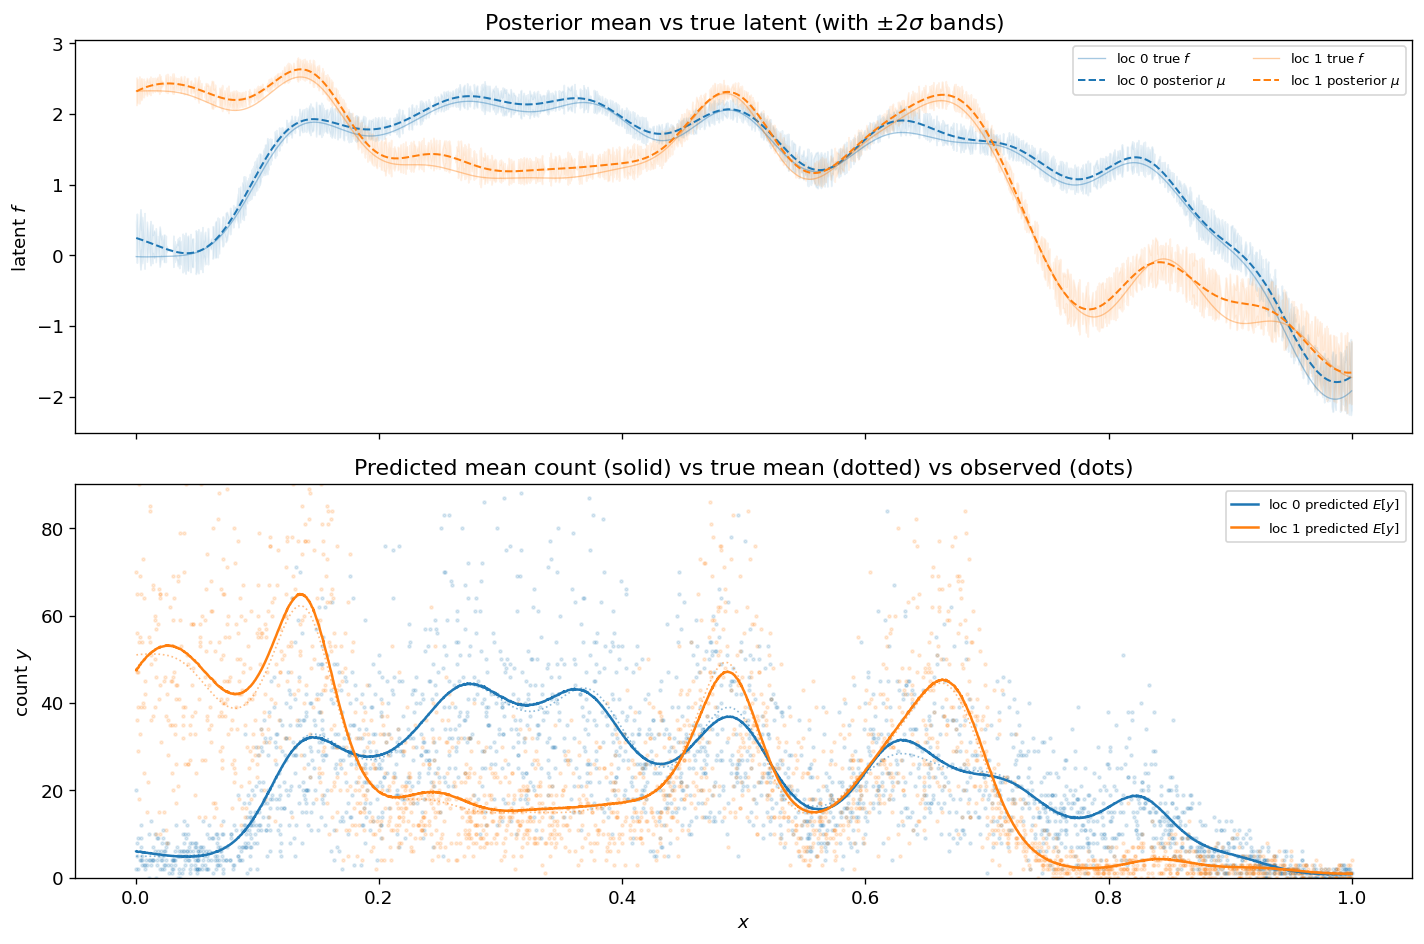

In [7]:
mu = model.mean_
sigma_diag = model.sigma_diag_
r_learned = model.total_count_

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Latent function ---
ax = axes[0]
for ell in range(L):
    mask = locations == ell
    o = np.argsort(x[mask])
    xs, ft, mu_e, sd = x[mask][o], f_true[mask][o], mu[mask][o], np.sqrt(np.clip(sigma_diag[mask][o], 0, None))
    c = colors[ell]
    ax.plot(xs, ft, color=c, alpha=0.4, lw=0.8, label=f"loc {ell} true $f$")
    ax.plot(xs, mu_e, color=c, lw=1.2, ls="--", label=f"loc {ell} posterior $\\mu$")
    ax.fill_between(xs, mu_e - 2*sd, mu_e + 2*sd, color=c, alpha=0.1)
ax.set_ylabel("latent $f$")
ax.legend(fontsize=8, ncol=2)
ax.set_title("Posterior mean vs true latent (with $\\pm 2\\sigma$ bands)")

# --- Predicted mean count vs observed ---
ax = axes[1]
pred_count = r_learned * np.exp(mu + 0.5 * np.clip(sigma_diag, 0, None))
for ell in range(L):
    mask = locations == ell
    o = np.argsort(x[mask])
    c = colors[ell]
    ax.scatter(x[mask], y[mask], s=3, alpha=0.15, color=c)
    ax.plot(x[mask][o], pred_count[mask][o], color=c, lw=1.5,
            label=f"loc {ell} predicted $E[y]$")
    # True mean
    true_mean = TRUE["r"] * np.exp(f_true[mask][o])
    ax.plot(x[mask][o], true_mean, color=c, lw=1, ls=":", alpha=0.5)
ax.set_ylabel("count $y$")
ax.set_xlabel("$x$")
ax.set_ylim(0, np.percentile(y, 99))
ax.legend(fontsize=8)
ax.set_title("Predicted mean count (solid) vs true mean (dotted) vs observed (dots)")

plt.tight_layout()
plt.show()

## 6b. Posterior decomposition: fitted $\hat{g}$ and $\hat{h}_\ell$ vs true

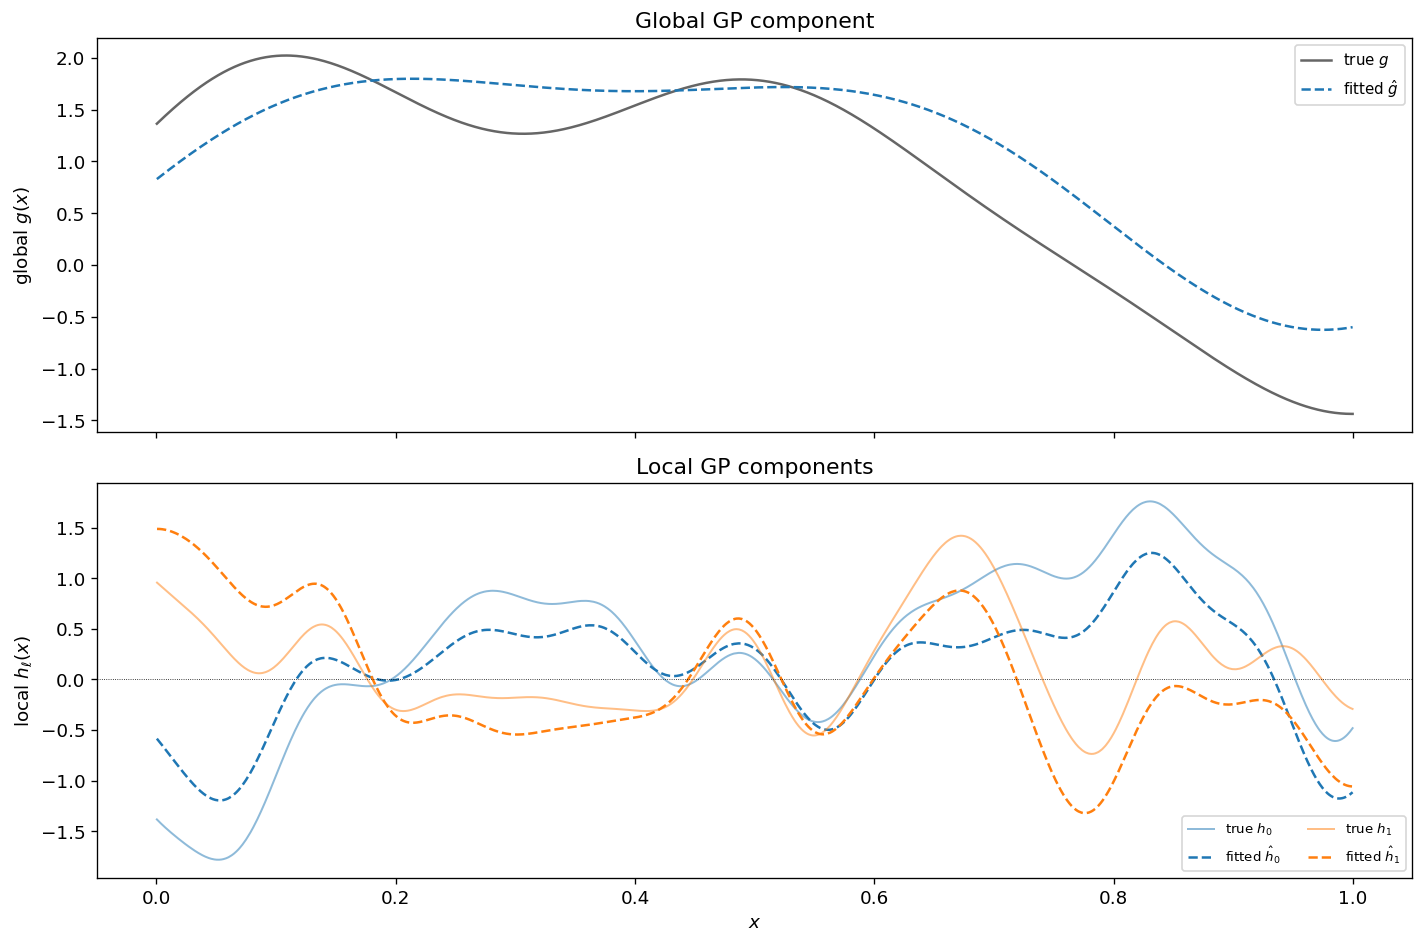

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

order = np.argsort(x)
g_hat = model.g_hat_
h_hats = model.h_hats_

# Top: global GP
ax = axes[0]
ax.plot(x[order], g[order], "k-", lw=1.5, alpha=0.6, label="true $g$")
ax.plot(x[order], g_hat[order], "C0--", lw=1.5, label="fitted $\\hat{g}$")
ax.set_ylabel("global $g(x)$")
ax.legend(fontsize=9)
ax.set_title("Global GP component")

# Bottom: local GPs per location
ax = axes[1]
for ell in range(L):
    mask = locations == ell
    o = np.argsort(x[mask])
    c = colors[ell]
    ax.plot(x[mask][o], h[mask][o], color=c, lw=1.2, alpha=0.5,
            label=f"true $h_{ell}$")
    ax.plot(x[mask][o], h_hats[ell][o], color=c, ls="--", lw=1.5,
            label=f"fitted $\\hat{{h}}_{ell}$")
ax.axhline(0, color="k", ls=":", lw=0.5)
ax.set_ylabel("local $h_\\ell(x)$")
ax.set_xlabel("$x$")
ax.legend(fontsize=8, ncol=2)
ax.set_title("Local GP components")

plt.tight_layout()
plt.show()

## 7. CG iteration counts over training

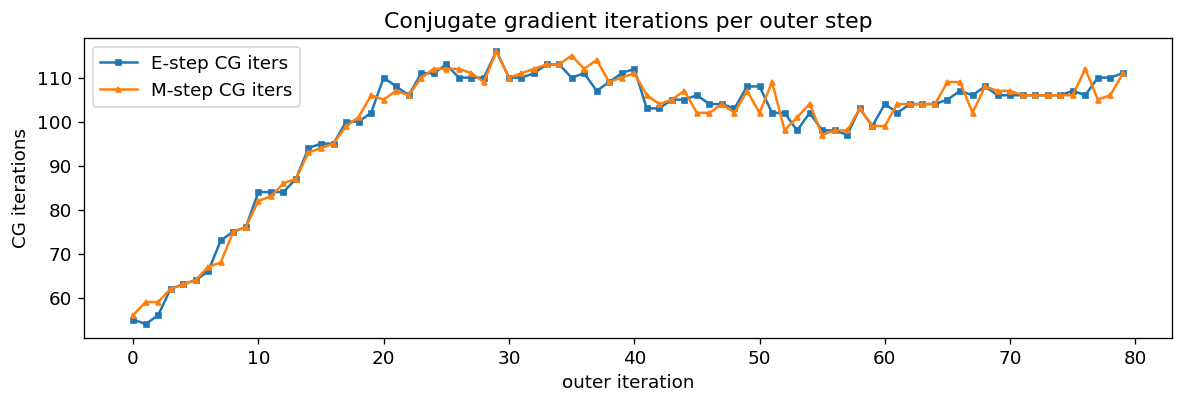

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(iters, [h["e_cg"] for h in hist], "s-", ms=3, label="E-step CG iters")
ax.plot(iters, [h["m_cg"] for h in hist], "^-", ms=3, label="M-step CG iters")
ax.set_xlabel("outer iteration")
ax.set_ylabel("CG iterations")
ax.legend()
ax.set_title("Conjugate gradient iterations per outer step")
plt.tight_layout()
plt.show()

## 8. Hyperparameter trajectory in (lengthscale, variance) space

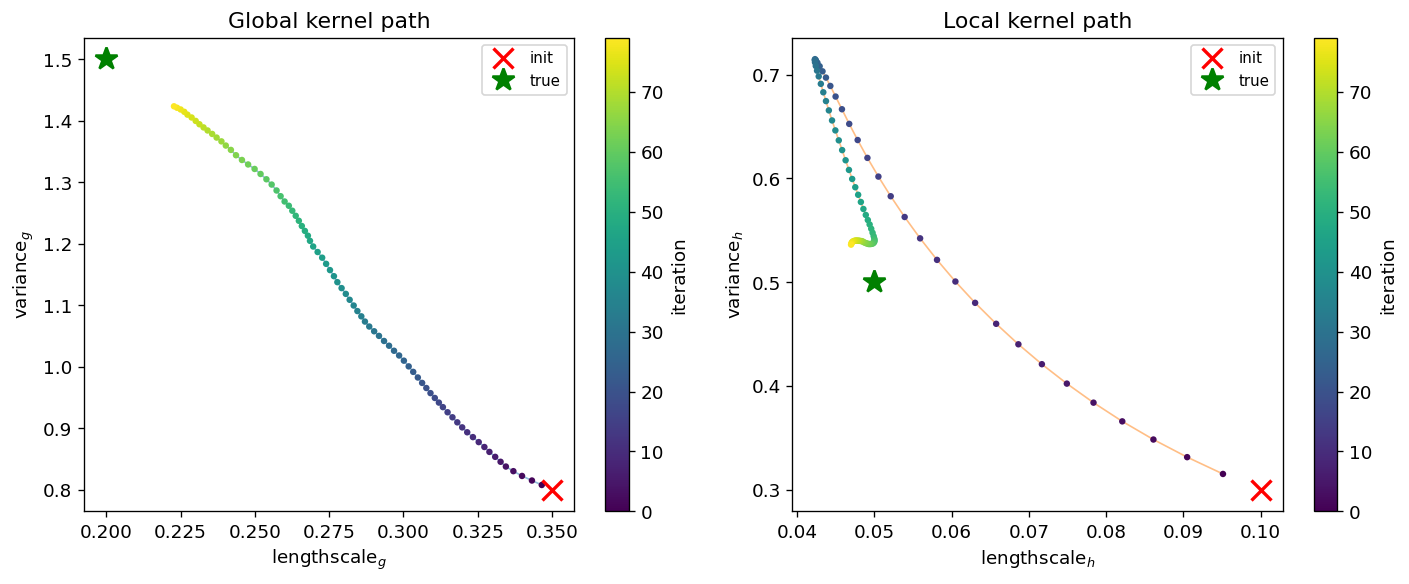

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Global kernel trajectory
ax = axes[0]
ls_path = [h["ls_g"] for h in hist]
var_path = [h["var_g"] for h in hist]
ax.plot(ls_path, var_path, "-", color="C0", alpha=0.5, lw=1)
ax.scatter(ls_path, var_path, c=iters, cmap="viridis", s=15, zorder=3, edgecolors="none")
ax.plot(INIT["ls_g"], INIT["var_g"], "rx", ms=12, mew=2, label="init", zorder=4)
ax.plot(TRUE["ls_g"], TRUE["var_g"], "g*", ms=14, mew=1.5, label="true", zorder=4)
ax.set_xlabel("lengthscale$_g$")
ax.set_ylabel("variance$_g$")
ax.legend(fontsize=9)
ax.set_title("Global kernel path")
cb = plt.colorbar(ax.collections[0], ax=ax, label="iteration")

# Local kernel trajectory
ax = axes[1]
ls_path = [h["ls_h"] for h in hist]
var_path = [h["var_h"] for h in hist]
ax.plot(ls_path, var_path, "-", color="C1", alpha=0.5, lw=1)
sc = ax.scatter(ls_path, var_path, c=iters, cmap="viridis", s=15, zorder=3, edgecolors="none")
ax.plot(INIT["ls_h"], INIT["var_h"], "rx", ms=12, mew=2, label="init", zorder=4)
ax.plot(TRUE["ls_h"], TRUE["var_h"], "g*", ms=14, mew=1.5, label="true", zorder=4)
ax.set_xlabel("lengthscale$_h$")
ax.set_ylabel("variance$_h$")
ax.legend(fontsize=9)
ax.set_title("Local kernel path")
plt.colorbar(sc, ax=ax, label="iteration")

plt.tight_layout()
plt.show()

## 9. Residual diagnostics

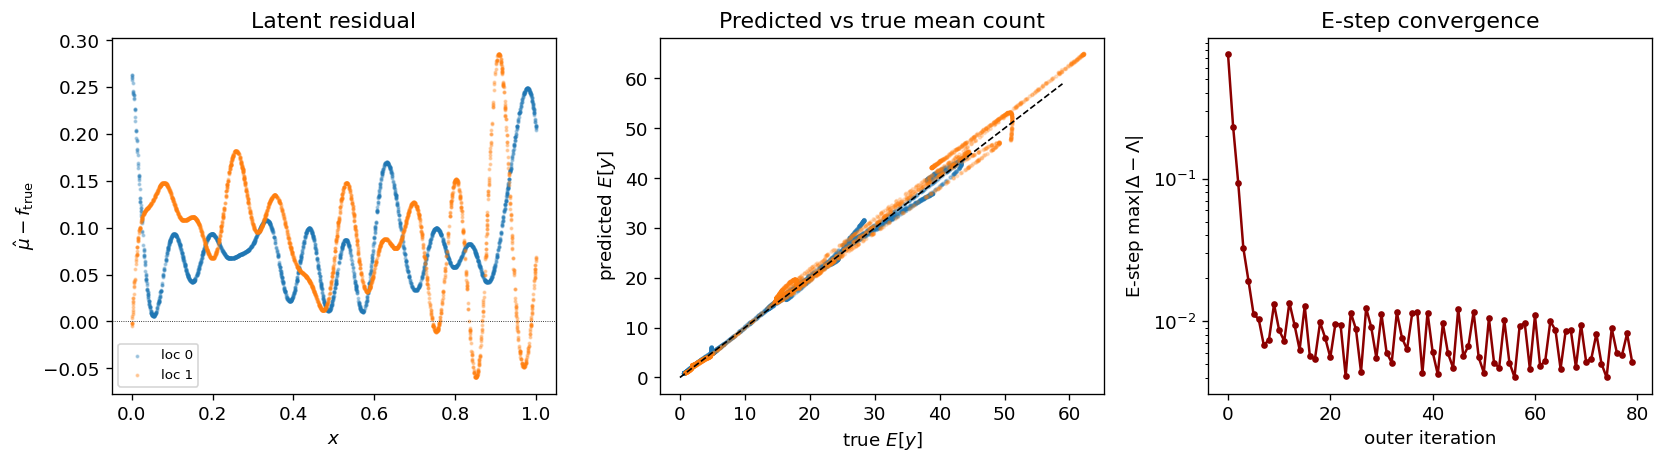

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Latent residual
resid_f = mu - f_true
ax = axes[0]
for ell in range(L):
    mask = locations == ell
    ax.scatter(x[mask], resid_f[mask], s=2, alpha=0.3, color=colors[ell], label=f"loc {ell}")
ax.axhline(0, color="k", ls=":", lw=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$\\hat\\mu - f_{\\mathrm{true}}$")
ax.set_title("Latent residual")
ax.legend(fontsize=8)

# Predicted vs true count
ax = axes[1]
true_mean_count = TRUE["r"] * np.exp(f_true)
ax.scatter(true_mean_count, pred_count, s=3, alpha=0.2, c=[colors[l] for l in locations])
lims = [0, min(np.percentile(true_mean_count, 99), np.percentile(pred_count, 99))]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("true $E[y]$")
ax.set_ylabel("predicted $E[y]$")
ax.set_title("Predicted vs true mean count")

# E-step convergence
ax = axes[2]
ax.plot(iters, [h["e_resid"] for h in hist], "o-", ms=3, color="darkred")
ax.set_yscale("log")
ax.set_xlabel("outer iteration")
ax.set_ylabel("E-step $\\max|\\Delta - \\Lambda|$")
ax.set_title("E-step convergence")

plt.tight_layout()
plt.show()

## 10. Timing breakdown

Total wall time: 55.5s
Mean per iteration: 0.70s
Block feature-space dim: (1 + 2) * 0.3465174436569214 -> see spectral state


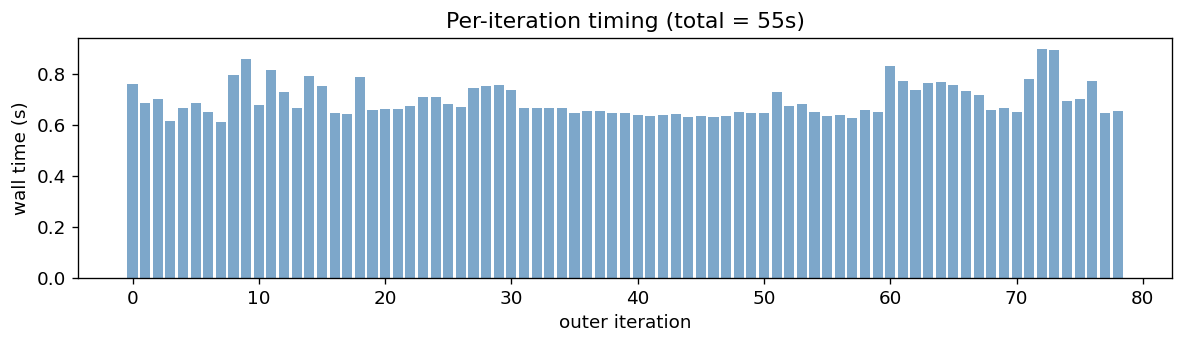

In [12]:
elapsed = [h["elapsed"] for h in hist]
per_iter = np.diff(elapsed)
total = elapsed[-1]

print(f"Total wall time: {total:.1f}s")
print(f"Mean per iteration: {np.mean(per_iter):.2f}s")
print(f"Block feature-space dim: (1 + {L}) * {model.history_[0].get('ls_g', '?')} -> see spectral state")

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(per_iter)), per_iter, color="steelblue", alpha=0.7)
ax.set_xlabel("outer iteration")
ax.set_ylabel("wall time (s)")
ax.set_title(f"Per-iteration timing (total = {total:.0f}s)")
plt.tight_layout()
plt.show()

## 11. Effect of number of locations on identifiability

Does having more locations (more independent replicates of $h_\ell$) help separate the global and local kernels? We fix $n=5000$ total and vary $L \in \{2, 5, 10\}$.

In [13]:
def generate_and_fit(n_total, n_locs, max_iter=80, seed_data=42, seed_fit=123):
    """Generate data with n_locs locations and fit the hierarchical model."""
    rng = np.random.default_rng(seed_data)
    xs = rng.uniform(0, 1, size=n_total)
    
    # Assign locations as evenly as possible
    locs = np.zeros(n_total, dtype=int)
    per_loc = n_total // n_locs
    for ell in range(n_locs):
        start = ell * per_loc
        end = (ell + 1) * per_loc if ell < n_locs - 1 else n_total
        locs[start:end] = ell

    # Global GP
    g_draw = rff_gp_sample(xs, seed=seed_data + 100,
                            lengthscale=TRUE["ls_g"], variance=TRUE["var_g"])

    # Local GPs
    h_draw = np.zeros(n_total)
    for ell in range(n_locs):
        mask = locs == ell
        h_draw[mask] = rff_gp_sample(xs[mask], seed=seed_data + 200 + ell,
                                      lengthscale=TRUE["ls_h"], variance=TRUE["var_h"])

    f_draw = g_draw + h_draw
    prob = 1.0 / (1.0 + np.exp(-f_draw))
    ys = rng.negative_binomial(TRUE["r"], 1 - prob).astype(np.float64)

    mdl = HierarchicalPGNegBinRegressor(
        lengthscale_g_init=INIT["ls_g"],
        variance_g_init=INIT["var_g"],
        lengthscale_h_init=INIT["ls_h"],
        variance_h_init=INIT["var_h"],
        total_count=INIT["r"],
        learn_total_count=True,
        total_count_lr=0.02,
        total_count_update_freq=3,
        max_iter=max_iter,
        e_step_iters=3,
        final_e_step_iters=5,
        lr_g=0.01,
        lr_h=0.05,
        n_e_probes=10,
        n_m_probes=10,
        cg_tol=1e-5,
        spectral_eps=1e-4,
        trunc_eps=1e-4,
        seed=seed_fit,
        verbose=0,
        device="cpu",
    )
    mdl.fit(xs, ys, locs)
    return mdl

In [14]:
L_values = [2, 5, 10]
results = {}

for L_val in L_values:
    print(f"Fitting L={L_val} ...", end=" ", flush=True)
    mdl = generate_and_fit(n_total=5000, n_locs=L_val)
    results[L_val] = mdl
    print(f"ls_g={mdl.lengthscale_g_:.4f}  var_g={mdl.variance_g_:.4f}  "
          f"ls_h={mdl.lengthscale_h_:.4f}  var_h={mdl.variance_h_:.4f}  "
          f"r={mdl.total_count_:.3f}")

Fitting L=2 ... 

ls_g=0.2228  var_g=1.4234  ls_h=0.0470  var_h=0.5363  r=4.668
Fitting L=5 ... 

ls_g=0.1990  var_g=1.5056  ls_h=0.0477  var_h=0.4921  r=4.721
Fitting L=10 ... 

ls_g=0.2024  var_g=1.4677  ls_h=0.0489  var_h=0.4722  r=4.672


In [15]:
# Summary table
rows = []
for L_val in L_values:
    m = results[L_val]
    rows.append({
        "L": L_val,
        "n/L": 5000 // L_val,
        "ls_g": m.lengthscale_g_,
        "var_g": m.variance_g_,
        "ls_h": m.lengthscale_h_,
        "var_h": m.variance_h_,
        "r": m.total_count_,
        "|ls_g err|": abs(m.lengthscale_g_ - TRUE["ls_g"]) / TRUE["ls_g"],
        "|var_g err|": abs(m.variance_g_ - TRUE["var_g"]) / TRUE["var_g"],
        "|ls_h err|": abs(m.lengthscale_h_ - TRUE["ls_h"]) / TRUE["ls_h"],
        "|var_h err|": abs(m.variance_h_ - TRUE["var_h"]) / TRUE["var_h"],
        "|r err|": abs(m.total_count_ - TRUE["r"]) / TRUE["r"],
    })

df = pd.DataFrame(rows).set_index("L")
# Format the error columns as percentages
for col in [c for c in df.columns if c.startswith("|")]:
    df[col] = df[col].map("{:.1%}".format)
df

,n/L,ls_g,var_g,ls_h,var_h,r,|ls_g err|,|var_g err|,|ls_h err|,|var_h err|,|r err|
L,,,,,,,,,,,
2,2500,0.222808,1.423356,0.046969,0.536270,4.668370,11.4%,5.1%,6.1%,7.3%,6.6%
5,1000,0.199046,1.505556,0.047672,0.492139,4.720936,0.5%,0.4%,4.7%,1.6%,5.6%
10,500,0.202368,1.467727,0.048866,0.472203,4.672147,1.2%,2.2%,2.3%,5.6%,6.6%


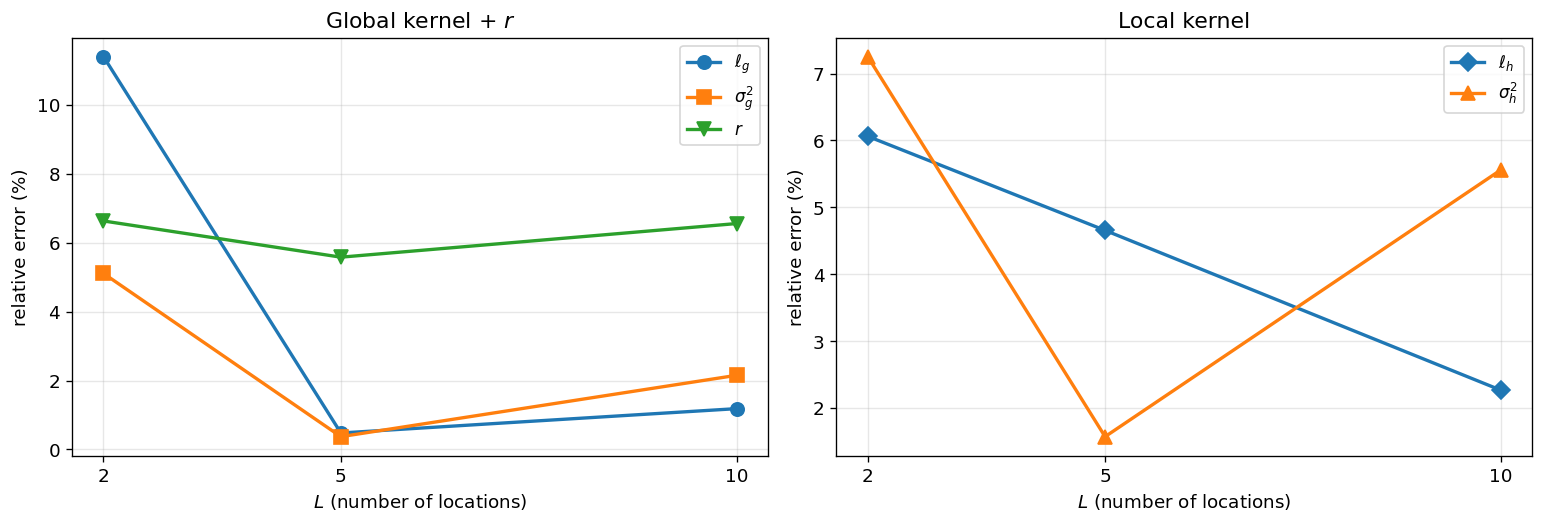

In [16]:
# Visualize: relative error vs L for each hyperparameter
attr_map = {"ls_g": "lengthscale_g_", "var_g": "variance_g_",
            "ls_h": "lengthscale_h_", "var_h": "variance_h_", "r": "total_count_"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
param_names = ["ls_g", "var_g", "ls_h", "var_h", "r"]
param_labels = ["$\\ell_g$", "$\\sigma^2_g$", "$\\ell_h$", "$\\sigma^2_h$", "$r$"]
markers = ["o", "s", "D", "^", "v"]

for ax, pidxs, title in [
    (axes[0], [0, 1, 4], "Global kernel + $r$"),
    (axes[1], [2, 3], "Local kernel"),
]:
    for pi in pidxs:
        pname = param_names[pi]
        true_val = TRUE[pname]
        errs = [abs(getattr(results[Lv], attr_map[pname]) - true_val) / true_val
                for Lv in L_values]
        ax.plot(L_values, [e * 100 for e in errs], f"{markers[pi]}-", ms=8, lw=2,
                label=param_labels[pi])
    ax.set_xlabel("$L$ (number of locations)")
    ax.set_ylabel("relative error (%)")
    ax.set_xticks(L_values)
    ax.legend(fontsize=10)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

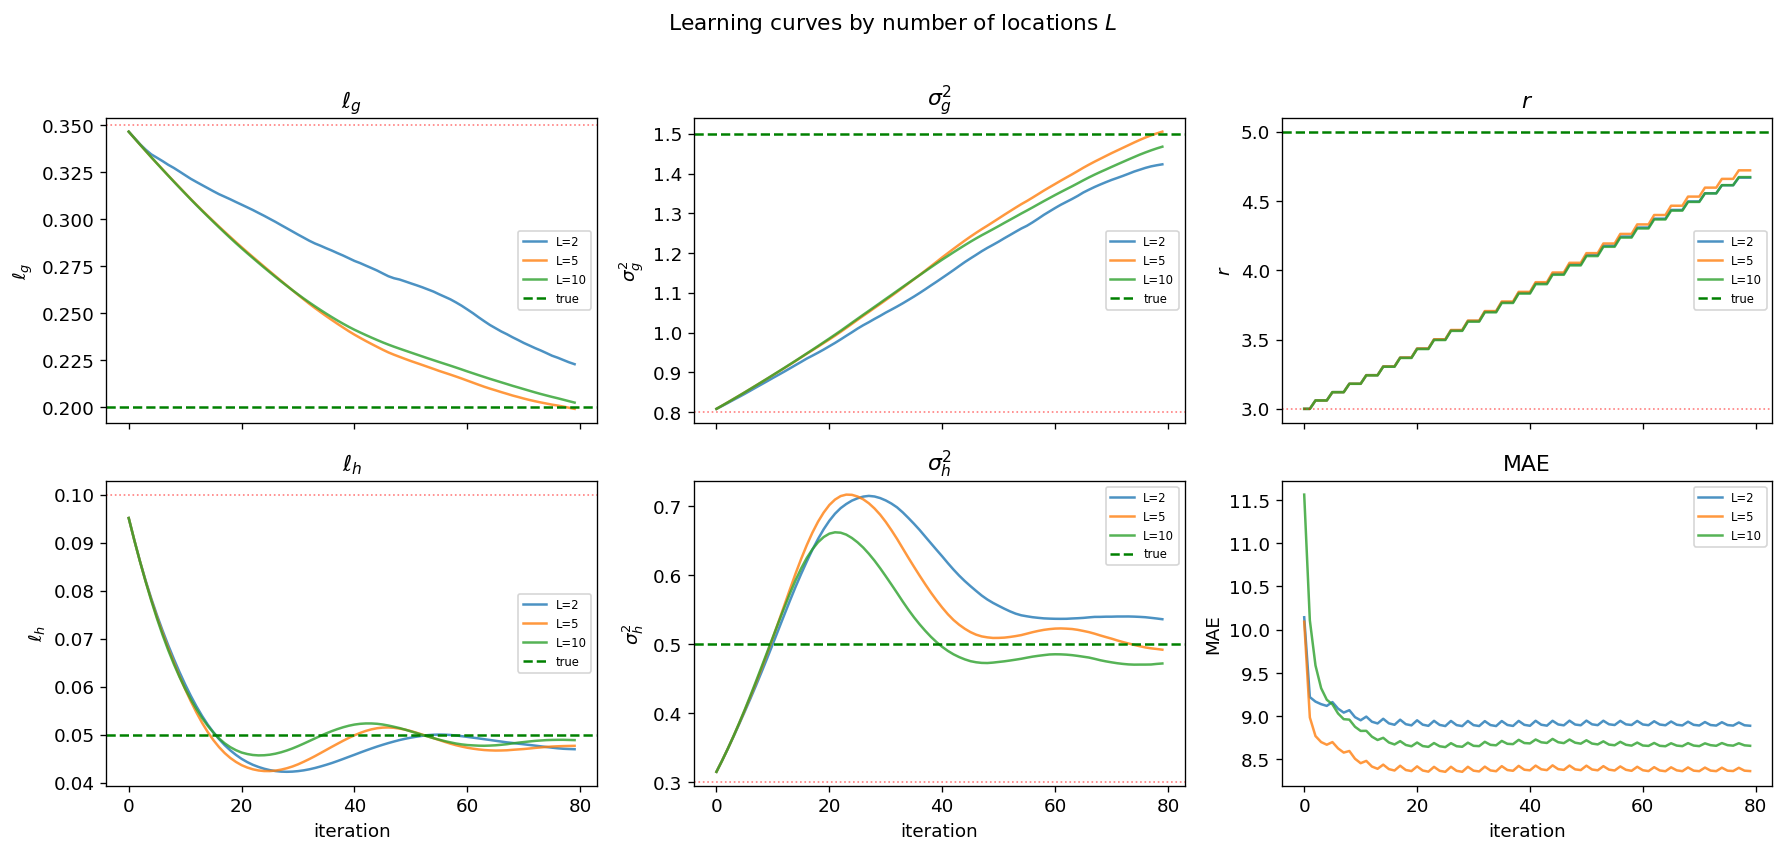

In [17]:
# Learning curves side by side for each L
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
titles_top = ["$\\ell_g$", "$\\sigma^2_g$", "$r$"]
keys_top = ["ls_g", "var_g", "r"]
true_top = [TRUE["ls_g"], TRUE["var_g"], TRUE["r"]]

titles_bot = ["$\\ell_h$", "$\\sigma^2_h$", "MAE"]
keys_bot = ["ls_h", "var_h", "mae"]
true_bot = [TRUE["ls_h"], TRUE["var_h"], None]

for col, (key, tval, title) in enumerate(zip(keys_top, true_top, titles_top)):
    ax = axes[0, col]
    for L_val in L_values:
        h = results[L_val].history_
        ax.plot([d["iter"] for d in h], [d[key] for d in h],
                label=f"L={L_val}", lw=1.5, alpha=0.8)
    ax.axhline(tval, color="green", ls="--", lw=1.5, label="true")
    ax.axhline(INIT[key], color="red", ls=":", lw=1, alpha=0.5)
    ax.set_ylabel(title)
    ax.legend(fontsize=7)
    ax.set_title(title)

for col, (key, tval, title) in enumerate(zip(keys_bot, true_bot, titles_bot)):
    ax = axes[1, col]
    for L_val in L_values:
        h = results[L_val].history_
        ax.plot([d["iter"] for d in h], [d[key] for d in h],
                label=f"L={L_val}", lw=1.5, alpha=0.8)
    if tval is not None:
        ax.axhline(tval, color="green", ls="--", lw=1.5, label="true")
        ax.axhline(INIT[key], color="red", ls=":", lw=1, alpha=0.5)
    ax.set_ylabel(title)
    ax.set_xlabel("iteration")
    ax.legend(fontsize=7)
    ax.set_title(title)

plt.suptitle("Learning curves by number of locations $L$", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()